In [1]:
import pandas as pd

red_df = pd.read_csv('https://raw.githubusercontent.com/prof-dana/Lecture-Code/refs/heads/main/AdvancedMachineLearning/data/winequality-red.csv', sep = ';')
white_df = pd.read_csv('https://raw.githubusercontent.com/prof-dana/Lecture-Code/refs/heads/main/AdvancedMachineLearning/data/winequality-white.csv', sep = ';')

print(red_df.head().T)
print(white_df.head().T)

                            0        1       2       3        4
fixed acidity          7.4000   7.8000   7.800  11.200   7.4000
volatile acidity       0.7000   0.8800   0.760   0.280   0.7000
citric acid            0.0000   0.0000   0.040   0.560   0.0000
residual sugar         1.9000   2.6000   2.300   1.900   1.9000
chlorides              0.0760   0.0980   0.092   0.075   0.0760
free sulfur dioxide   11.0000  25.0000  15.000  17.000  11.0000
total sulfur dioxide  34.0000  67.0000  54.000  60.000  34.0000
density                0.9978   0.9968   0.997   0.998   0.9978
pH                     3.5100   3.2000   3.260   3.160   3.5100
sulphates              0.5600   0.6800   0.650   0.580   0.5600
alcohol                9.4000   9.8000   9.800   9.800   9.4000
quality                5.0000   5.0000   5.000   6.000   5.0000
                            0        1        2         3         4
fixed acidity           7.000    6.300   8.1000    7.2000    7.2000
volatile acidity        0.270   

In [2]:
red_df['type'] = 'red'
white_df['type'] = 'white'

print(red_df.shape)
print(white_df.shape)

(1599, 13)
(4898, 13)


In [3]:
wine = pd.concat([red_df, white_df], axis = 0)
wine.shape

(6497, 13)

In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB


In [5]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
wine['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9], dtype=int64)

In [7]:
wine['quality'].value_counts() 

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [8]:
wine.groupby('type')['quality'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
red,1599.0,5.636023,0.807569,3.0,5.0,6.0,6.0,8.0
white,4898.0,5.877909,0.885639,3.0,5.0,6.0,6.0,9.0


In [9]:
wine.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [10]:
wine.groupby('type')['quality'].std()

type
red      0.807569
white    0.885639
Name: quality, dtype: float64

In [11]:
wine.groupby('type')['quality'].agg(['mean', 'std'])

,mean,std
type,,
red,5.636023,0.807569
white,5.877909,0.885639


In [17]:
#conda install statsmodels
from scipy import stats

red_wine_quality = wine[wine['type'] == 'red']['quality']
white_wine_quality = wine[wine['type'] == 'white']['quality']

stats.ttest_ind(red_wine_quality, white_wine_quality, equal_var = False)

TtestResult(statistic=-10.149363059143164, pvalue=8.168348870049682e-24, df=2950.750452166697)

In [26]:
Rformula = """
quality ~ Q("fixed acidity")
        + Q("volatile acidity")
        + Q("citric acid")
        + Q("residual sugar")
        + chlorides
        + Q("free sulfur dioxide")
        + Q("total sulfur dioxide")
        + density
        + pH
        + sulphates
        + alcohol
"""

regression_result = ols(Rformula, data=wine).fit()
regression_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     243.3
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:04:37   Log-Likelihood:                -7215.5
No. Observations:                6497   AIC:                         1.445e+04
Df Residuals:                    6485   BIC:                         1.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    55.7627     11.894      4.688      0.000      32.447      79.079
Q("fixed acidity")            0.0677      0.016      4.346      0.000       0.037       0.098
Q("volatile acidity")        -1.3279      0.077    -17.162      0.000      -1.480      -1.176
Q("citric acid")             -0.1097      0.080     -1.377      0.168      -0.266       0.046
Q("residual sugar")           0.0436      0.005      8.449      0.000       0.033       0.054
chlorides                    -0.4837      0.333     -1.454      0.146      -1.136       0.168
Q("free sulfur dioxide")      0.0060      0.001      7.948      0.000       0.004       0.007
Q("total sulfur dioxide")    -0.0025      0.000     -8.969      0.000      -0.003      -0.002
density                     -54.9669     12.137     -4.529      0.000     -78.760     -31.173
pH                            0.4393      0.090      4.861      0.000       0.262       0.616
sulphates                     0.7683      0.076     10.092      0.000       0.619       0.917
alcohol                       0.2670      0.017     15.963      0.000       0.234       0.300
==============================================================================
Omnibus:                      144.075   Durbin-Watson:                   1.646
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.712
Skew:                          -0.006   Prob(JB):                     3.09e-71
Kurtosis:                       4.095   Cond. No.                     2.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB


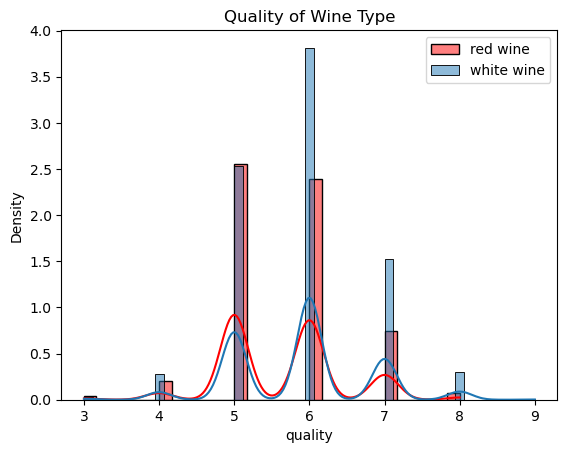

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(red_wine_quality, stat='density', kde = True, color = "red", label = 'red wine')
sns.histplot(white_wine_quality, stat='density', kde = True, label = 'white wine')
plt.title("Quality of Wine Type")
plt.legend()
plt.show()

In [31]:
titanic = sns.load_dataset("titanic")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [32]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [33]:
#결측값이 연속형이기 때문에 중앙값으로 채우기
titanic['age'] = titanic['age'].fillna(titanic['age'].median()) 

#결측값이 범주형이기 때문에 가장많이 나타난 값으로 채우기
print(titanic['embarked'].value_counts())
titanic['embarked'] = titanic['embarked'].fillna('S')

embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [34]:
#나머지도 마찬가지
print(titanic['embark_town'].value_counts())
titanic['embark_town'] = titanic['embark_town'].fillna('Southampton')

print(titanic['deck'].value_counts())
titanic['deck'] = titanic['deck'].fillna('C')

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64


In [35]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [36]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


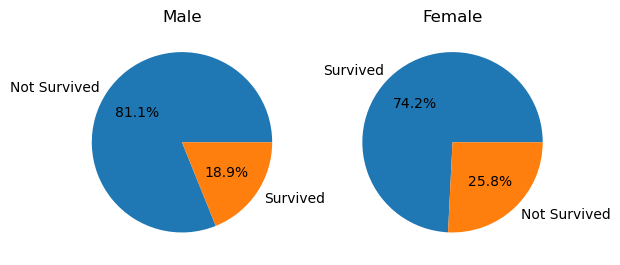

In [44]:
import matplotlib.pyplot as plt

#데이터 준비
male_count=titanic['survived'][titanic['sex'] == 'male'].value_counts()
female_count=titanic['survived'][titanic['sex'] == 'female'].value_counts()

#그리기
plt.subplot(1, 2, 1)
plt.pie(male_count, labels=['Not Survived', 'Survived'], autopct='%1.1f%%')
plt.title('Male')

plt.subplot(1, 2, 2)
plt.pie(female_count, labels=['Survived', 'Not Survived'], autopct='%1.1f%%')
plt.title('Female')

plt.show()

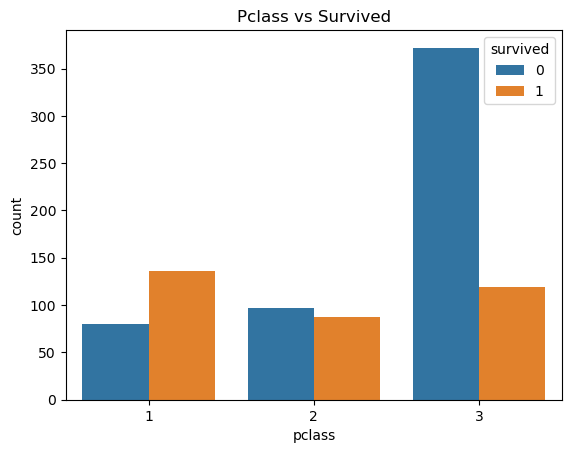

In [45]:
sns.countplot(x='pclass', hue = 'survived', data = titanic)
plt.title('Pclass vs Survived')
plt.show()

In [47]:
#숫자형 데이터 타입만 추출
titanic2 = titanic.select_dtypes(include=[int, float,bool]) 
titanic2.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.0,1,0,7.2500,True,False
1,1,1,38.0,1,0,71.2833,False,False
2,1,3,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,False
4,0,3,35.0,0,0,8.0500,True,True


In [48]:
titanic2.corr(method = 'pearson')

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.247704,0.171647
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.247704,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,0.404744,1.000000


In [49]:
print(titanic['survived'].corr(titanic['adult_male']))
print(titanic['survived'].corr(titanicsS['fare']))

-0.5570800422053258
0.25730652238496227


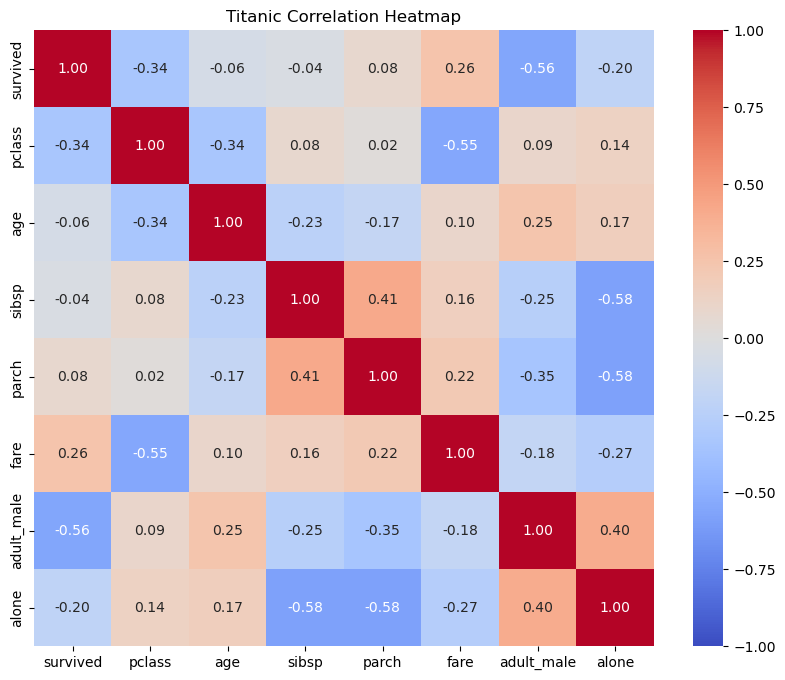

In [53]:
# 히트맵
plt.figure(figsize=(10, 8))

sns.heatmap(
    titanic2.corr(method = 'pearson'),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Titanic Correlation Heatmap")
plt.show()

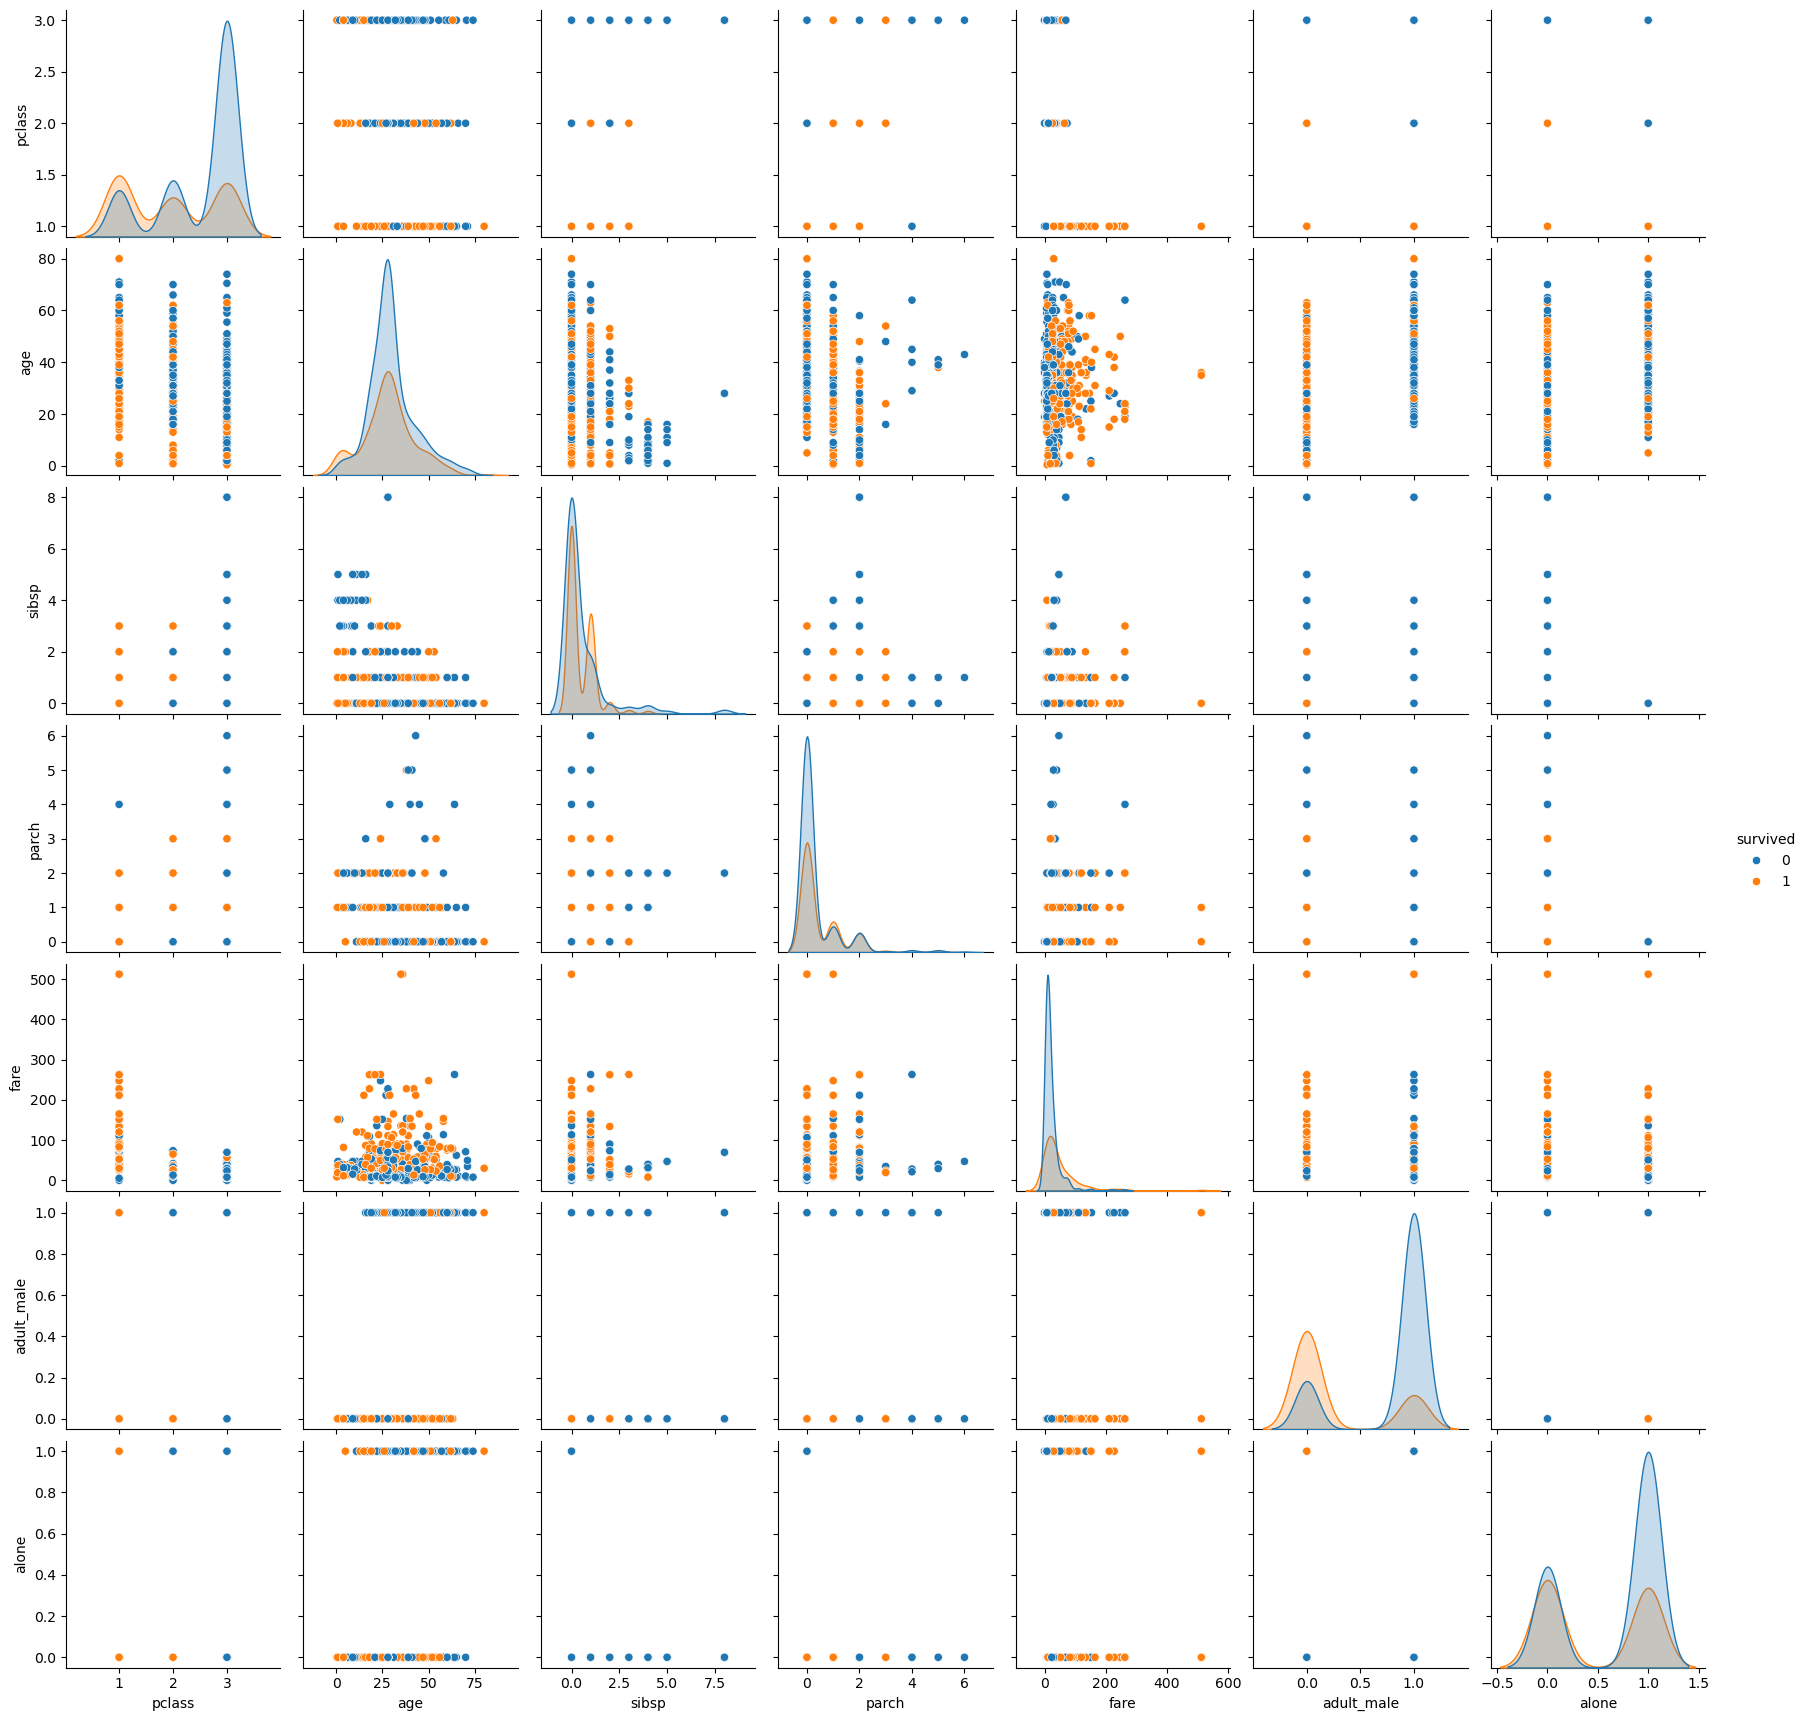

In [50]:
sns.pairplot(titanic, hue = 'survived')
plt.show()

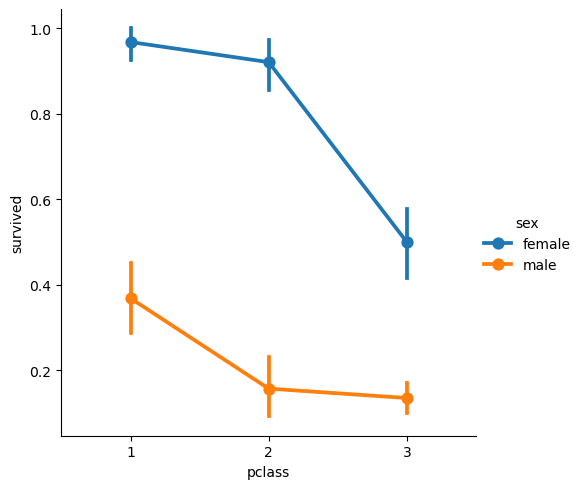

In [51]:
sns.catplot(x = 'pclass', y = 'survived', hue = 'sex', data = titanic, kind = 'point')
plt.show()